## Tutorial for computing transmission of Al with Tailwater + Kwant

In [1]:
#Define API Keys:
#Materials Project API Key
API_KEY = #Your Materials Project API Key
#Tailwater User + Password
TW_USER= # Your Tailwater Username
TW_PASS= #Your Tailwater Password

In [36]:
import os
from mp_api.client import MPRester
mp_id='mp-134' #Materials Project ID for Al
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

Querying the Materials Project for mp-134...


Retrieving SummaryDoc documents: 100%|█████████| 1/1 [00:00<00:00, 10407.70it/s]


Structure Summary
Lattice
    abc : 2.8559542459167657 2.855954291634759 2.855955
 angles : 60.00000337792521 60.00000284838631 60.00000242846307
 volume : 16.471717630914863
      A : 2.473329 0.0 1.427977
      B : 0.824442999999999 2.331877 1.427977
      C : 0.0 0.0 2.855955
    pbc : True True True
PeriodicSite: Al (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]

In [37]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)
import pybinding as pb
import matplotlib.pyplot as plt

In [38]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat")

In [39]:
# Load the HDF5 the API produced — returns a tbmodels.Model with .to_pb()
model = tb_model.load("outputs/wannier90_hr.hdf5")
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)

/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/spglib/spg.py:438: DeprecationWarning: Set OLD_ERROR_HANDLING to false and catch the errors directly.
  _set_no_error(_throw)


[bands] path total length = 3.6665  -> N_path = 184 samples (spacing = 0.02)


Band structure: 100%|███████████████████████| 184/184 [00:00<00:00, 6453.42it/s]


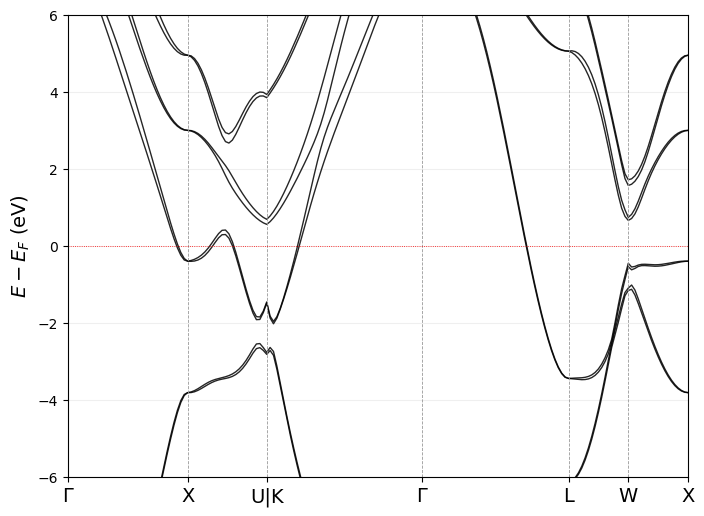

In [44]:
#Plot band structure using SeeKPath
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-6, 6))
fig

# Now we port the model to kwant and plot the bandstructure in Kwant

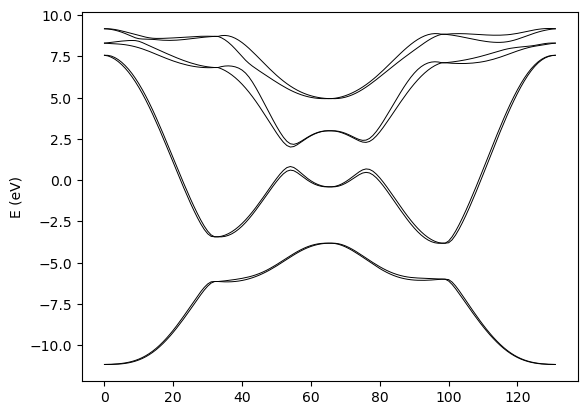

In [41]:
import numpy as np, kwant
import matplotlib.pyplot as plt
from tailwater import tb_model

syst  = kwant.wraparound.wraparound(model.to_kwant()).finalized()

# Gamma -> M -> K -> Gamma  (linearly sampled fractional path)
nodes = np.array([[0,0,0], [0,0,0.5],[-0.5,0,0.5], [-0.5,0,0], [0,0,0]])
path  = np.vstack([np.linspace(nodes[i], nodes[i+1], 33)
                   for i in range(len(nodes) - 1)])

bands = []
for k_frac in path:
    phase = 2 * np.pi * k_frac
    H = syst.hamiltonian_submatrix(
        params=dict(k_x=phase[0], k_y=phase[1], k_z=phase[2]),
    )
    bands.append(np.sort(np.linalg.eigvalsh(H)))
bands = np.array(bands)                       # (Npts, num_wann)

fig, ax = plt.subplots()
ax.plot(bands, lw=0.7, color="k")
ax.set_ylabel("E (eV)")
plt.show()

# Next lets set up a scattering problem 

bulk Builder:     8 orbitals in the 3D-periodic fundamental domain
scattering region: 128 sites (2x2x4 cells)
lead cross-section: 64 sites


/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/kwant/_plotter.py:416: MatplotlibDeprecationWarning: The proj_transform_clip function was deprecated in Matplotlib 3.10 and will be removed in 3.12.
  vs = np.array(proj(xs, ys, zs, self.axes.M)[:3])
/opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/kwant/_plotter.py:472: MatplotlibDeprecationWarning: The proj_transform_clip function was deprecated in Matplotlib 3.10 and will be removed in 3.12.
  cz = proj(*(list(np.dot(corners, bbox)) + [self.axes.M]))[2]


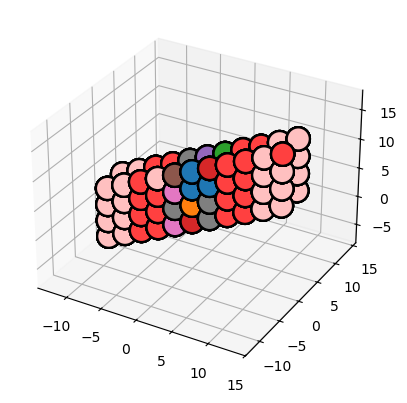

finalize:           0.1 s (192 total nodes)

Sampling G(E) ...
    E (eV)      T(E)    time
    -3.000     4.000    1.1s
    -2.700    10.000    1.3s
    -2.400     8.000    1.2s
    -2.100     4.000    0.8s
    -1.800     2.000    1.1s
    -1.500     4.000    1.2s
    -1.200    10.000    1.0s
    -0.900     8.000    1.2s
    -0.600    14.000    1.2s
    -0.300    16.000    1.2s
    +0.000     6.000    1.1s
    +0.300    10.000    1.1s
    +0.600     8.000    1.1s
    +0.900    12.000    1.1s
    +1.200    10.000    1.1s
    +1.500    10.000    1.0s
    +1.800    10.000    1.2s
    +2.100     8.000    1.0s
    +2.400    12.000    1.3s
    +2.700    10.000    1.2s
    +3.000    10.000    1.1s

Wrote kwant_conductance.png and kwant_conductance.npz


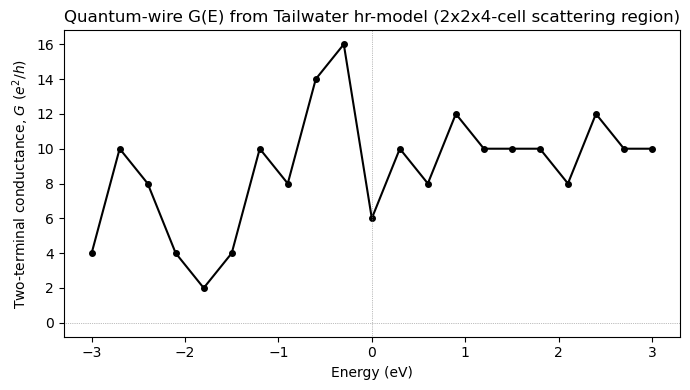

In [45]:
"""Quantum-wire scattering: Tailwater hr-model → Kwant transport.

Takes a Tailwater Wannier hr-model (e.g. the API's output),
exports it to a Kwant Builder via ``model.to_kwant()``, carves out
a finite scattering region, attaches two semi-infinite leads, and
sweeps the two-terminal conductance G(E) = (e^2/h) * T(E) across an
energy window.

The geometry is a 3D Wannier model `bulk`, with:

    transport direction      = a_1  (first row of the lattice, in-plane)
    finite cross-section     = Ly cells along a_2 x Lz cells along a_3

The scattering region is a rectangular block of `Lx * Ly * Lz` unit
cells; both leads share the same `Ly * Lz` cross-section and extend
to +/-infinity along a_1. Kwant computes the scattering matrix via
the wave-function method.

Run-time scales as O((Ly * Lz)^3 * Lx) for each energy. The default
parameters below (Lx=4, Ly=2, Lz=2) take ~2 minutes on a laptop CPU.
For publication-quality results you typically want a thicker
cross-section (e.g. Ly=Lz=6+) so finite-size quantization doesn't
mask the bulk band edges, and a denser energy grid; expect the cost
to grow accordingly.

Requires:
    pip install tailwater
    conda install -c conda-forge kwant         # kwant is heavy; use conda
"""

import time

import numpy as np
import matplotlib.pyplot as plt

import kwant
from tailwater import tb_model


# ----------------------------------------------------------------------
# Geometry
# ----------------------------------------------------------------------
# Keep these small for a quick demo. The matrix size of the scattering
# region scales as Lx * Ly * Lz * num_wann; for the 124-orbital Bi2Se3
# hr-model that is ~2k sites at the defaults below.
LX, LY, LZ = 2,2,4

# Energy grid for the G(E) sweep, in eV (zero is the API's reference,
# typically Fermi-shifted). Adjust as needed.
ENERGIES = np.linspace(-3.0, 3.0, 21)


def in_scattering_region(site, Lx, Ly, Lz):
    """A finite Lx * Ly * Lz block of unit cells."""
    x, y, z = site.tag
    return (0 <= x < Lx) and (0 <= y < Ly) and (0 <= z < Lz)


def in_lead_cross_section(site, Ly, Lz):
    """The lead's transverse cross-section: a Ly * Lz tile."""
    _, y, z = site.tag
    return (0 <= y < Ly) and (0 <= z < Lz)


def main():
    # ------------------------------------------------------------------
    # 1)  Load the hr-model and export to Kwant
    # ------------------------------------------------------------------
    #model = tb_model.load("outputs/wannier90_hr.hdf5")
    bulk  = model.to_kwant()
    print(f"bulk Builder:     {sum(1 for _ in bulk.sites())} orbitals "
          f"in the 3D-periodic fundamental domain")

    # Kwant returns its lattice periods wrapped in a custom array
    # class — cast to a regular ndarray before indexing.
    periods = np.asarray(bulk.symmetry.periods)         # (3, 3) Cartesian rows

    # ------------------------------------------------------------------
    # 2)  Carve out a finite scattering region from the bulk template.
    # ------------------------------------------------------------------
    syst = kwant.Builder()                              # no symmetry — finite
    syst.fill(
        bulk,
        shape=lambda site: in_scattering_region(site, LX, LY, LZ),
        start=(0, 0, 0),
    )
    print(f"scattering region: {sum(1 for _ in syst.sites())} sites "
          f"({LX}x{LY}x{LZ} cells)")

    # ------------------------------------------------------------------
    # 3)  Build a lead — 1D-periodic along a_1 (transport direction),
    #     finite along the other two.
    # ------------------------------------------------------------------
    sym_lead = kwant.TranslationalSymmetry(periods[0])
    lead     = kwant.Builder(sym_lead)
    lead.fill(
        bulk,
        shape=lambda site: in_lead_cross_section(site, LY, LZ),
        start=(0, 0, 0),
    )
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    print(f"lead cross-section: {sum(1 for _ in lead.sites())} sites")
    kwant.plot(syst);

    # ------------------------------------------------------------------
    # 4)  Finalise and sweep G(E)
    # ------------------------------------------------------------------
    t0 = time.time()
    fsyst = syst.finalized()
    print(f"finalize:           {time.time() - t0:.1f} s "
          f"({fsyst.graph.num_nodes} total nodes)")

    print()
    print("Sampling G(E) ...")
    print(f"  {'E (eV)':>8}  {'T(E)':>8}  {'time':>6}")
    transmissions = np.zeros_like(ENERGIES)
    for k, E in enumerate(ENERGIES):
        t0 = time.time()
        try:
            smatrix         = kwant.smatrix(fsyst, energy=float(E))
            transmissions[k] = smatrix.transmission(1, 0)
            ok               = True
        except Exception as exc:                        # noqa: BLE001
            transmissions[k] = np.nan
            ok               = False
            print(f"  {E:>+8.3f}    FAIL   {type(exc).__name__}")
            continue
        if ok:
            print(f"  {E:>+8.3f}  {transmissions[k]:>8.3f}  "
                  f"{time.time() - t0:>5.1f}s")

    # ------------------------------------------------------------------
    # 5)  Save the raw data and plot G(E)
    # ------------------------------------------------------------------
    

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ENERGIES, transmissions, "k-o", lw=1.5, ms=4)
    ax.axhline(0, ls=":", color="gray", lw=0.5)
    ax.axvline(0, ls=":", color="gray", lw=0.5)        # E_F reference
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel(r"Two-terminal conductance, $G$ ($e^2/h$)")
    ax.set_title(
        f"Quantum-wire G(E) from Tailwater hr-model "
        f"({LX}x{LY}x{LZ}-cell scattering region)"
    )
    fig.tight_layout()
    #fig.savefig("kwant_conductance.png", dpi=160)
    print()
    print("Wrote kwant_conductance.png and kwant_conductance.npz")


if __name__ == "__main__":
    main()